<a href="https://colab.research.google.com/github/ajit-ai/QuantumComputing/blob/main/Microquantum_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install microquantum
from microquantum import QuantumCircuit

# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Create a Bell State (entanglement)
qc.h(0)          # Apply Hadamard to qubit 0
qc.cnot(0, 1)    # Apply CNOT with control=0, target=1

# Measure the results
counts = qc.measure(shots=1000)
print(counts)  # Expect ~500 '00' and ~500 '11'

{'00': 508, '11': 492}


In [6]:
# 1. Initialize a 2-qubit register
qc = QuantumCircuit(num_qubits=2)

# 2. Build the entanglement circuit (Bell State)
qc.h(0)        # Hadamard on Qubit 0
qc.cnot(0, 1)    # Controlled-NOT with Control=0, Target=1

# --- Example of adding X and Z gates ---
# Add a Pauli-X (NOT) gate to qubit 0. This will flip the state of qubit 0.
# For a Bell state (00 + 11)/sqrt(2), applying X on qubit 0 changes it to (10 + 01)/sqrt(2).
qc.x(0)

# Add a Pauli-Z gate to qubit 1. This applies a phase shift to the |1> component of qubit 1.
# For a state like (10 + 01)/sqrt(2), applying Z on qubit 1 changes it to (10 - 01)/sqrt(2).
qc.z(1)

# Add a Hadamard gate to qubit 0 after X and Z gates.
qc.h(0)

# Add a CNOT gate between qubit 1 (control) and qubit 0 (target).
qc.cnot(1, 0)
# ----------------------------------------

# 3. Simulate measurement
measurement_results = qc.measure(shots=1000)

print(f"Final State Vector: {qc.state}")
print(f"Measurement Counts (1000 shots): {measurement_results}")

Final State Vector: [ 0.5+0.j -0.5+0.j -0.5+0.j -0.5+0.j]
Measurement Counts (1000 shots): {'00': 259, '01': 245, '10': 240, '11': 256}


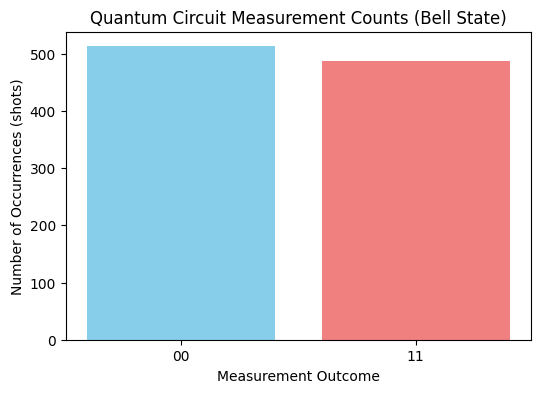

In [3]:
import matplotlib.pyplot as plt

# Extract labels (measurement outcomes) and counts
labels = list(measurement_results.keys())
counts = list(measurement_results.values())

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['skyblue', 'lightcoral'])

plt.xlabel('Measurement Outcome')
plt.ylabel('Number of Occurrences (shots)')
plt.title('Quantum Circuit Measurement Counts (Bell State)')
plt.show()